### Loading Packages & Configs

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from loader import load_data, get_batch
from tokenizer import Tokenizer
from train import Trainer
from dataclasses import dataclass
from plot_metrics import plot_metrics_history, plot_history
%load_ext autoreload
%autoreload 2

In [2]:
@dataclass
class Config:
    batch_size: int = 4
    vocab_size: int = None
    seq_len: int = 8
    n_layer: int = 4
    max_iters: int = 5000
    eval_interval: int = 500
    learning_rate: float = 3e-4
    device: str = 'mps' if torch.mps.is_available() else 'cpu'
    eval_iters: int = 200
    n_embd: int = 32
    n_head: int = 4
    data_split: float = 0.9

### Loading Data

In [3]:
text = load_data(filename="data/sample-TinyStories.txt")

Number of stories: 73
Length of text: 57107 characters


### Building Tokenizer & Train, Val dataset

In [4]:
tokenizer = Tokenizer(text)

In [5]:
print(f"Vocabulary size: {tokenizer.vocab_size}")

Vocabulary size: 61


In [6]:
config = Config(vocab_size=tokenizer.vocab_size)

In [7]:
data = tokenizer.encode(text)
data = torch.tensor(data, dtype=torch.long)

In [8]:
train_data = data[:int(config.data_split*len(data))]
val_data = data[int(config.data_split*len(data)):]
print(f"Train data length: {len(train_data)}")

Train data length: 51396


### GPT Architecture

### Training Model

In [43]:
model = BasicGPT()
model = model.to(config.device)

In [44]:
parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {parameters} | Number of trainable parameters: {parameters/1e6:.2f}M")

Parameters: 4221 | Number of trainable parameters: 0.00M


In [ ]:
trainer = Trainer(model, train_data, val_data, config)

trainer.set_experiment("pos-embed + self-atten")  
trainer.train()

trainer.save_history("logs/experiment_history.json")
trainer.save_metrics('logs/metrics.json')

step    500 | train loss 3.3222 | val loss 3.2885 |    1.84 ms/step |     17473 tok/s 
step   1000 | train loss 2.9128 | val loss 2.8793 |    1.82 ms/step |     17540 tok/s 
step   1500 | train loss 2.7541 | val loss 2.7542 |    2.14 ms/step |     14920 tok/s 
step   2000 | train loss 2.6211 | val loss 2.6551 |    2.15 ms/step |     14907 tok/s 
step   2500 | train loss 2.5964 | val loss 2.5635 |    1.79 ms/step |     17913 tok/s 
step   3000 | train loss 2.5381 | val loss 2.5048 |    2.21 ms/step |     14511 tok/s 
step   3500 | train loss 2.4841 | val loss 2.4873 |    1.99 ms/step |     16048 tok/s 
step   4000 | train loss 2.4595 | val loss 2.4803 |    1.89 ms/step |     16939 tok/s 
step   4500 | train loss 2.4698 | val loss 2.4792 |    1.90 ms/step |     16808 tok/s 


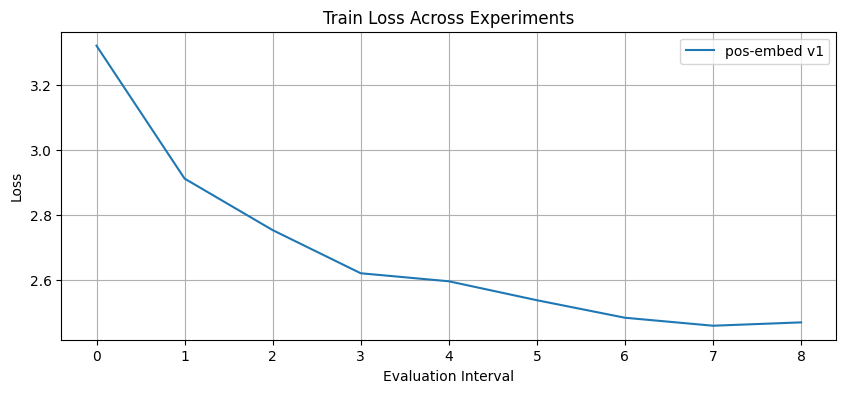

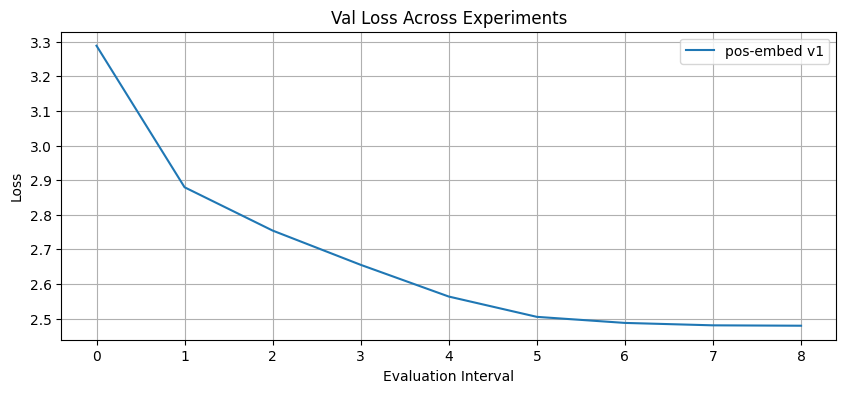

In [46]:
plot_history('logs/experiment_history.json','train')
plot_history('logs/experiment_history.json','val')

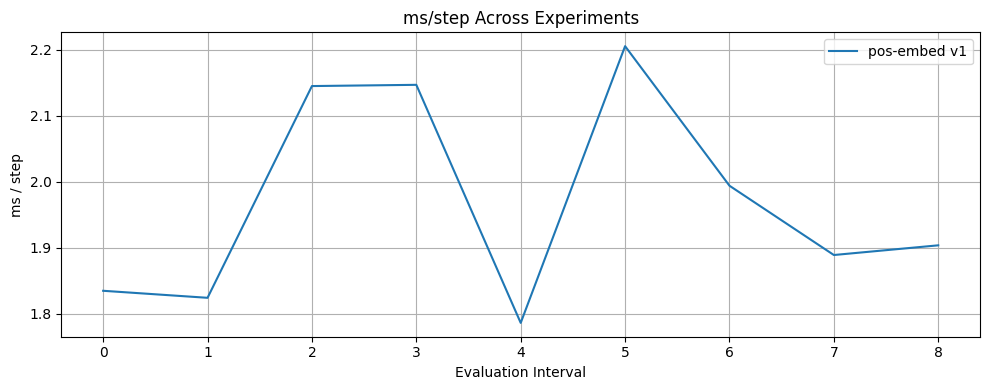

In [47]:

plot_metrics_history('logs/metrics.json', metric='ms_per_step')

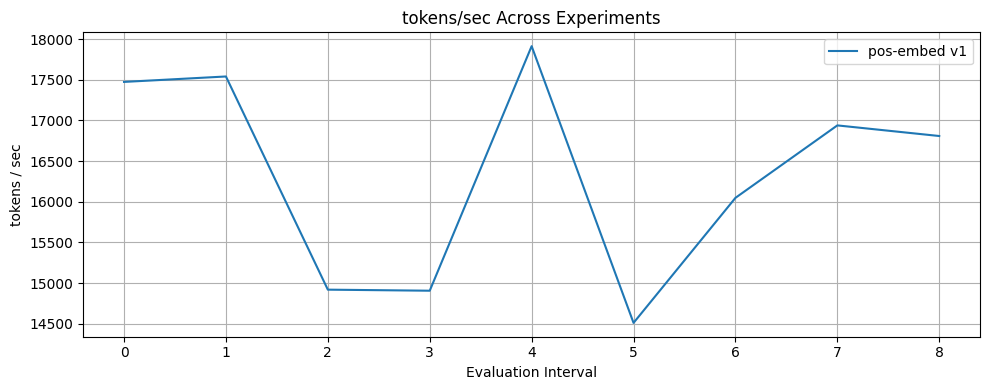

In [48]:
plot_metrics_history('logs/metrics.json', metric='tok_per_sec')

In [130]:
context = torch.zeros((1,1),dtype=torch.long,device='mps')

In [131]:
tokens = model.generate(context,1000).tolist()

In [132]:
print(tokenizer.decode(tokens))



"ke woe led. yamand cam ce sang we fie waked bond Tnund d sound Thedpom lan ann thmantokd goroled, hii.nowasor. finrhe we. the lo athenthered and ly Ay ls ten. ther.
?k avs. w Hen thouby nthes sithe truibeyuh tha " bB, Lir, n. fitoot wamre ltheand.thed wey q ind itome , Ter ved asithernc a f. fan alou, rlispadit. wy be t.l ve an l an theolok.
"Hed tanseykele and hea, t wato! plily ! man, Tom. hecadotouny the s t wan f yore st d to.


Thed Sitome Fsamme wabe w he he shit Sadspo ppy, "! c m sian!h t S" atoanery, owasotoy ten s."T. we tt thenthlythet The Tholinon fad tker tha s shFe ihem as y tey me bar w, ly. wn wihend.am thngoud ay spt he avayad lehe othetoasu,d. Tdom hindy, litt te l s t a weds smW- tomy ashapastlthin cy tterunoysund amo hthiy"hheS d s t Third- towasud. timet Tllothe " wan o w addang g isatid wedr.
n t n ner.

veno. gy. The spy amer tihesthd m: thed te ogt. ad fu w ckwan ard Th tsed bil ore. Ted w sanaowe c
m w w s. lwthes az. aroom d ar
"
themM. wo lan an rdusroud k